# Test di fit_utils.py


Questo notebook verifica `lin_fit` con dati placebo costruiti a partire da una retta nota. La prima parte controlla il caso standard con sole incertezze su `y`; la seconda usa anche `sigma_x` secondo la varianza efficace descritta nelle dispense di riferimento.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import mespy as mlt


In [2]:
rng = np.random.default_rng(42)

x = np.arange(1, 11, dtype=float)
sigma_y = np.full_like(x, 0.5)

m_true = 2.5
c_true = 1.2
rumore = rng.normal(0.0, 0.5, size=x.size)
y = c_true + m_true * x + rumore

print("x =", x)
print("y =", np.round(y, 3))
print("sigma_y =", sigma_y)


x = [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
y = [ 3.852  5.68   9.075 11.67  12.724 15.549 18.764 21.042 23.692 25.773]
sigma_y = [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]


{'m': 2.4685443799290026,
 'c': 1.20522025618755,
 'sigma_m': 0.05504818825631803,
 'sigma_c': 0.3415650255319866,
 'cov_mc': -0.016666666666666666,
 'rho_mc': -0.8864052604279185,
 'r': array([ 0.1785939 , -0.46230107,  0.4643722 ,  0.59088458, -0.82345975,
        -0.46757629,  0.27888929,  0.08830341,  0.26947975, -0.11718602]),
 'sigma_r': 0.4846450197071033,
 'fig': <Figure size 2400x1800 with 2 Axes>,
 'n_iter': 0}

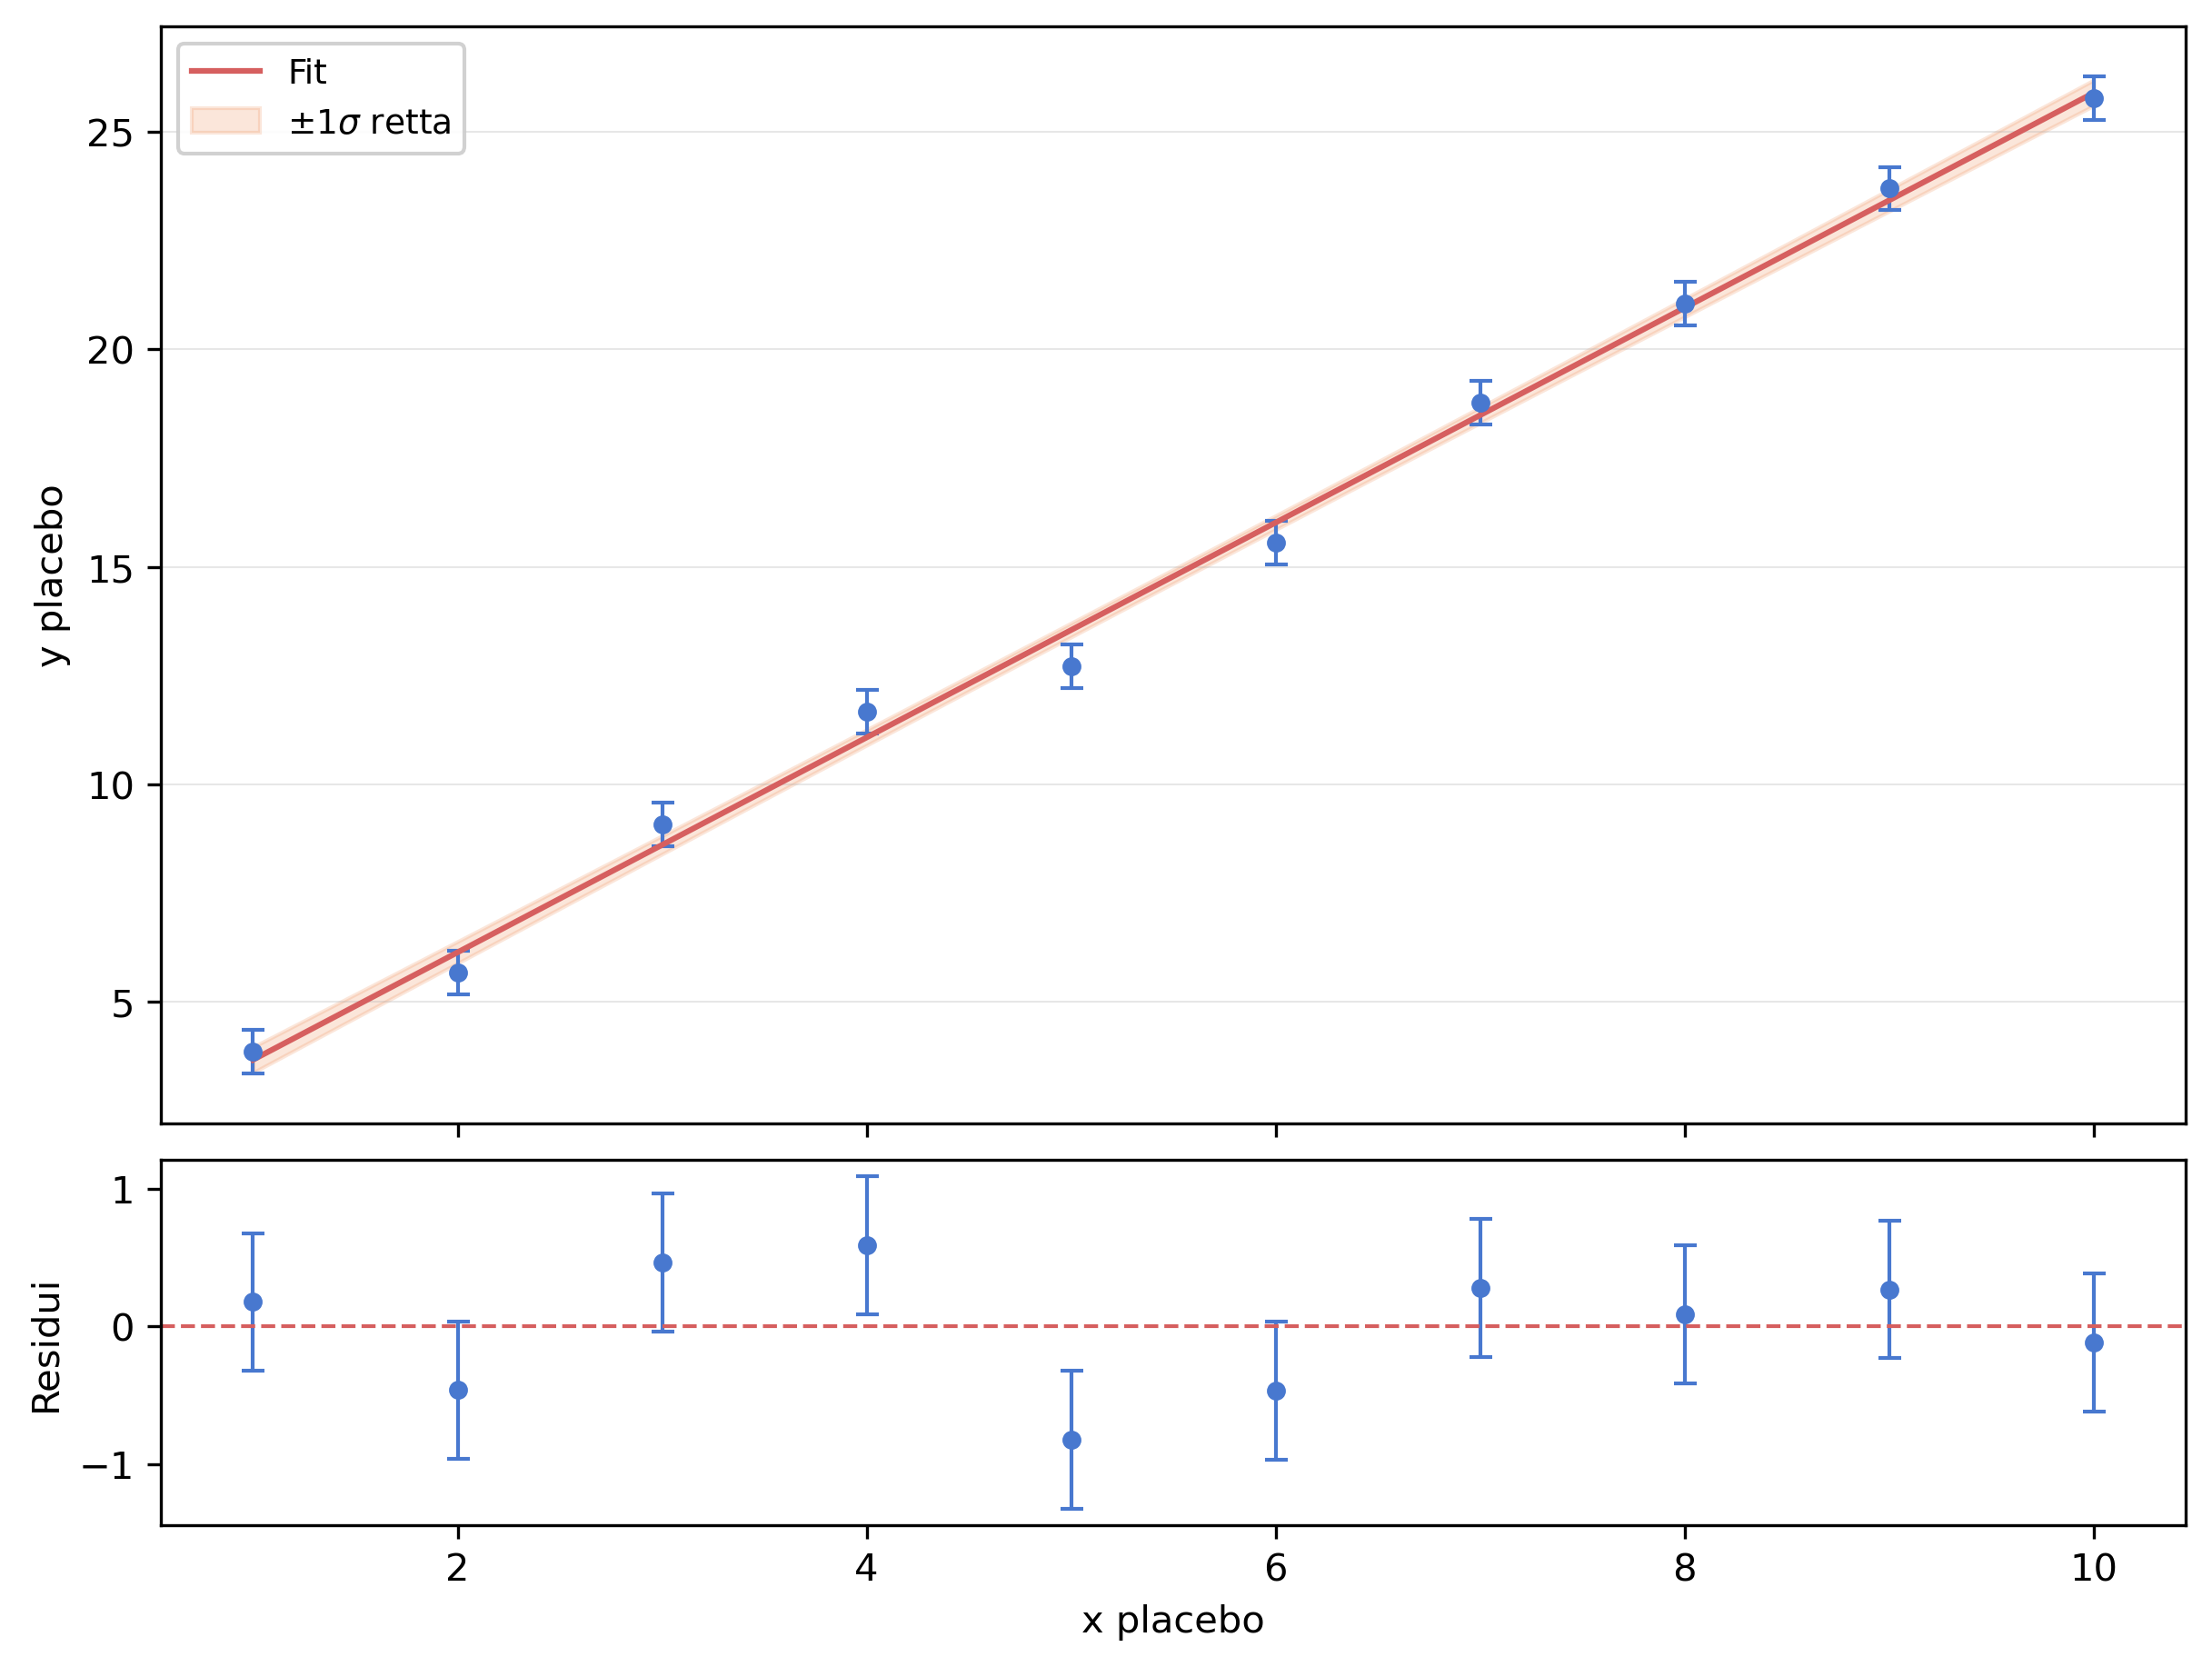

In [3]:
mlt.lin_fit(
    x,
    y,
    sigma_y,
    xlabel="x placebo",
    ylabel="y placebo",
    band=True,
    plot=True,
)


## Tutti i nuovi parametri in azione

Questo esempio mostra `xlim`, `ylim`, `decimals`, `legend` e `legend_coefficient` applicati insieme.


{'m': 2.4685443799290026,
 'c': 1.20522025618755,
 'sigma_m': 0.05504818825631803,
 'sigma_c': 0.3415650255319866,
 'cov_mc': -0.016666666666666666,
 'rho_mc': -0.8864052604279185,
 'r': array([ 0.1785939 , -0.46230107,  0.4643722 ,  0.59088458, -0.82345975,
        -0.46757629,  0.27888929,  0.08830341,  0.26947975, -0.11718602]),
 'sigma_r': 0.4846450197071033,
 'fig': <Figure size 2400x1800 with 2 Axes>,
 'n_iter': 0}

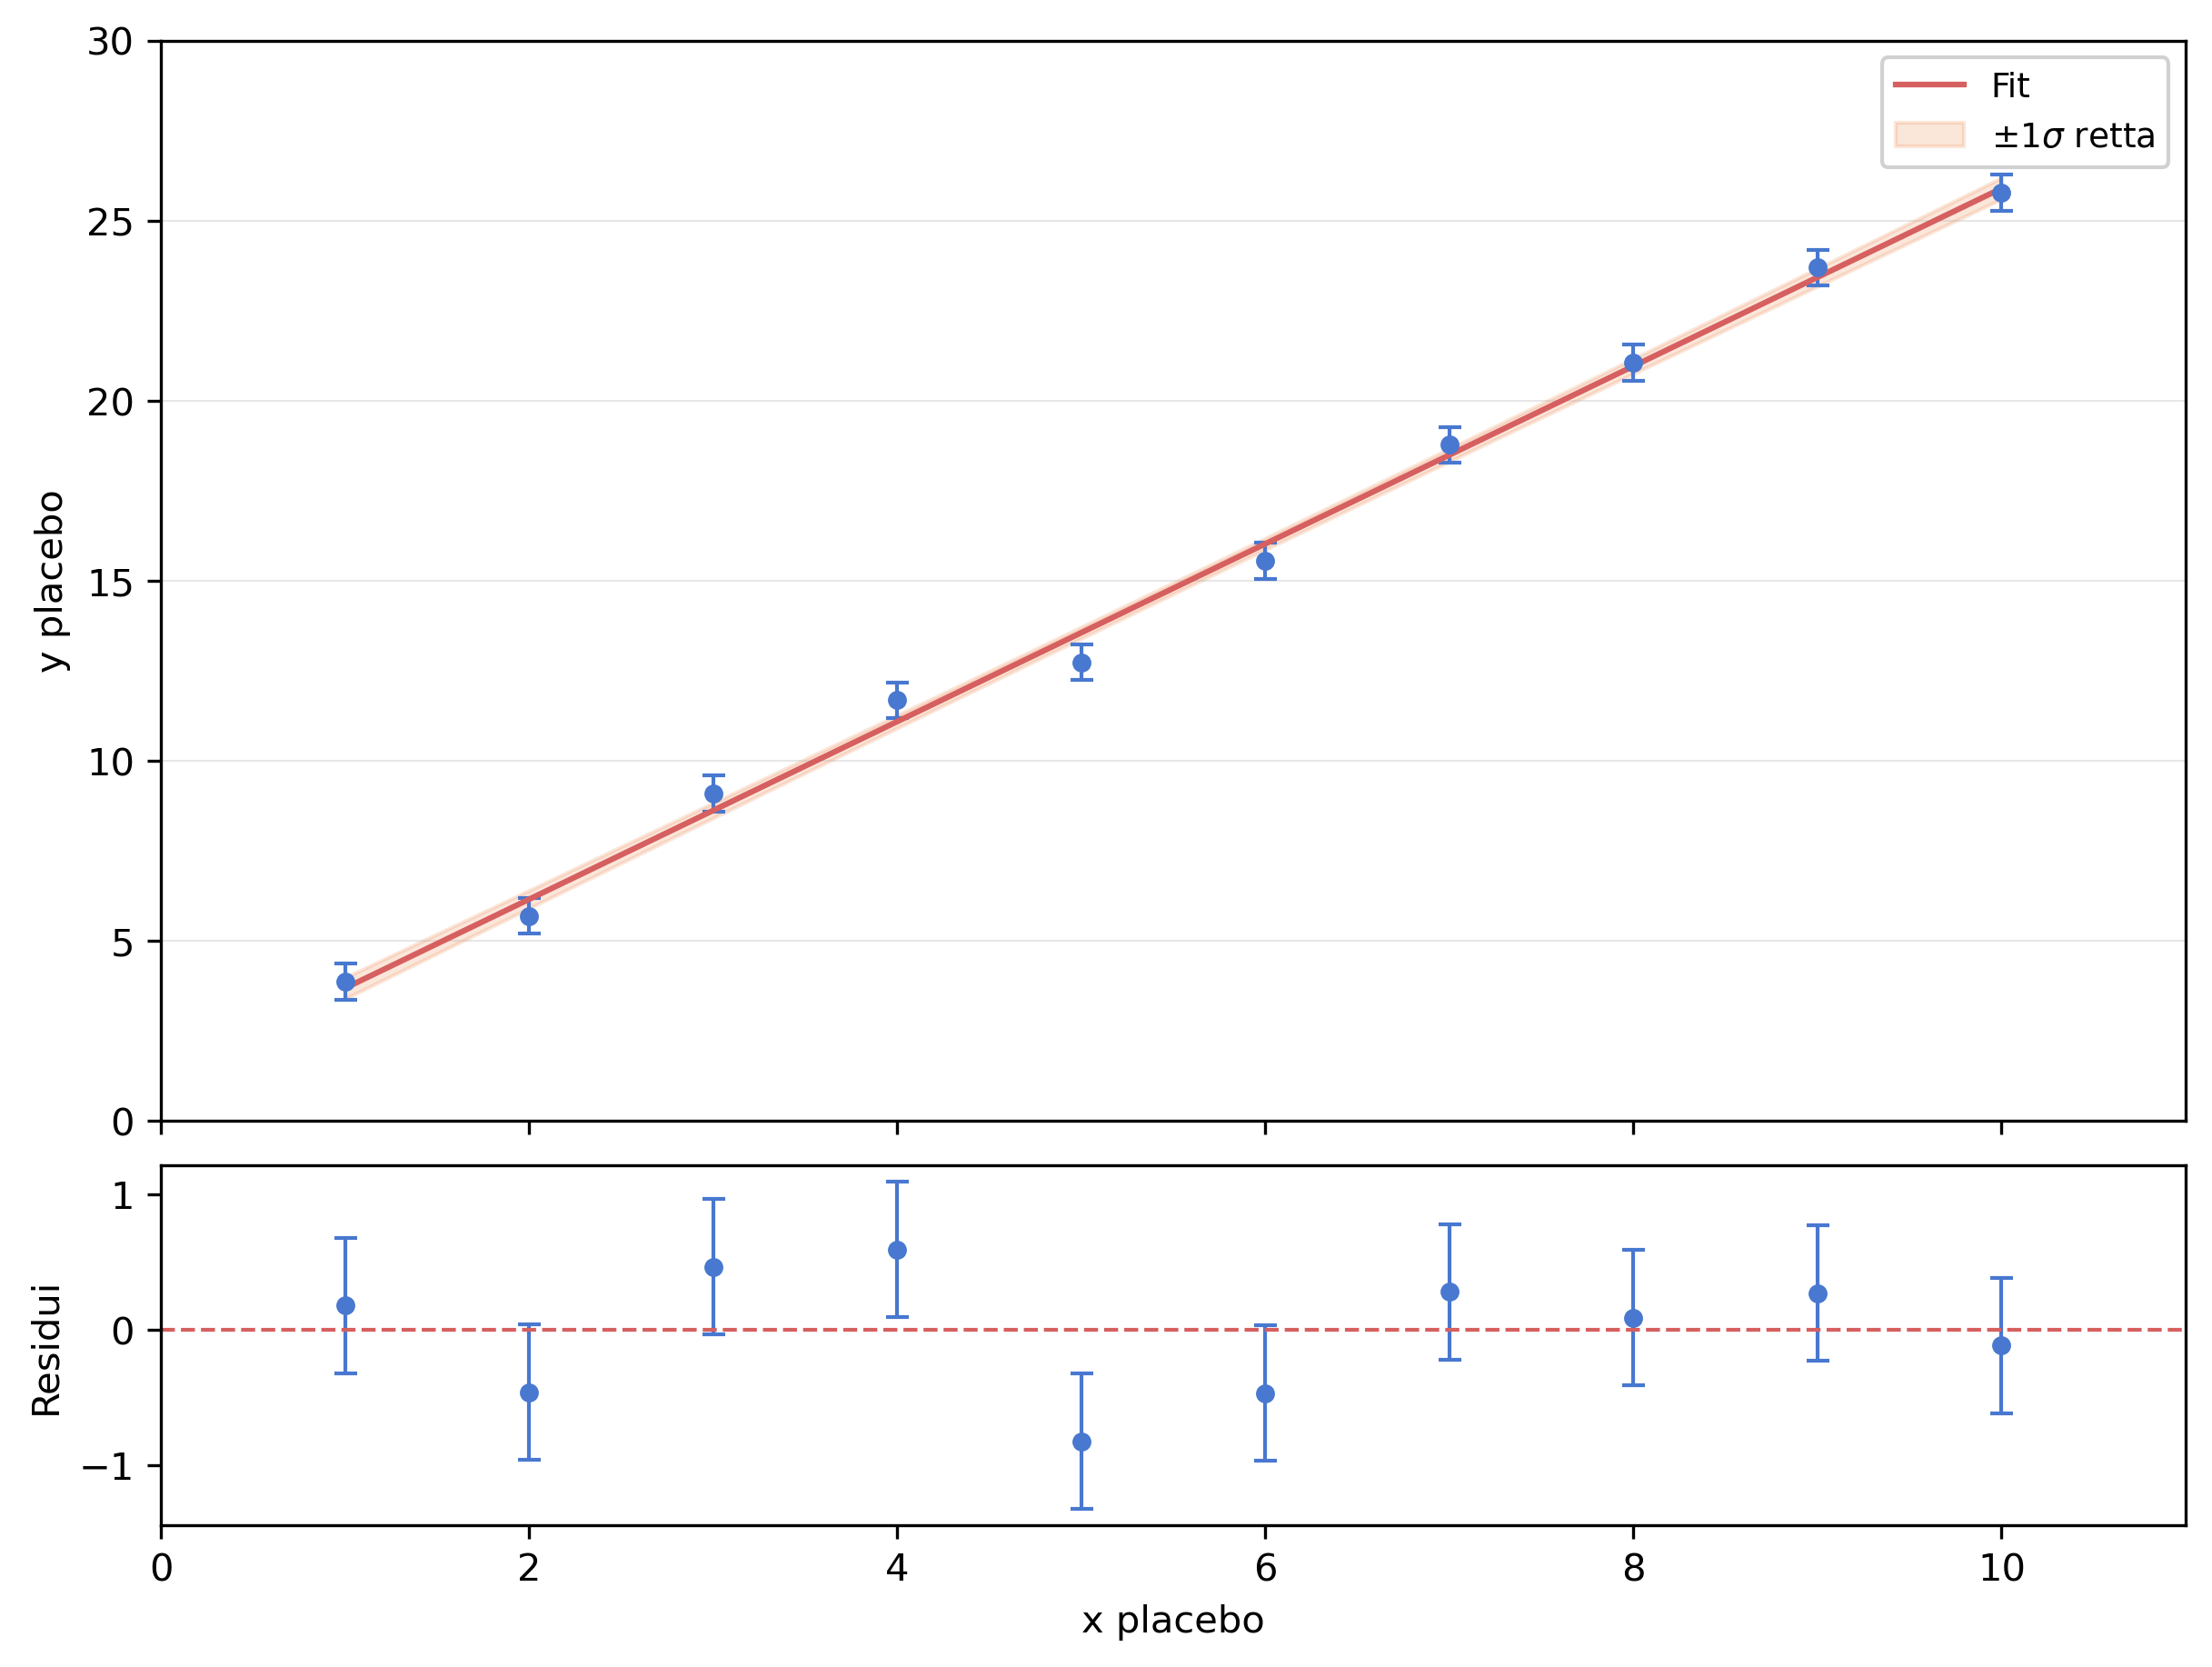

In [4]:
mlt.lin_fit(
    x,
    y,
    sigma_y,
    xlabel="x placebo",
    ylabel="y placebo",
    band=True,
    xlim=(0, 11),
    ylim=(0, 30),
    decimals=1,
    legend_coefficient=False,
)


## Test dedicato a `sigma_x`

Qui genero dati placebo in cui sia `x` sia `y` sono affetti da rumore. Il fit con `sigma_x` usa la varianza efficace `sigma_y^2 + m^2 sigma_x^2` e quindi aggiorna i pesi in modo iterativo.


In [5]:
rng_sigma_x = np.random.default_rng(123)

x_true_sigma_x = np.linspace(1.0, 10.0, 16)
sigma_x = np.linspace(0.08, 0.22, x_true_sigma_x.size)
sigma_y_sigma_x = np.full_like(x_true_sigma_x, 0.35)

m_true_sigma_x = 1.7
c_true_sigma_x = 0.9

x_obs = x_true_sigma_x + rng_sigma_x.normal(0.0, sigma_x)
y_obs = c_true_sigma_x + m_true_sigma_x * x_true_sigma_x + rng_sigma_x.normal(0.0, sigma_y_sigma_x)

fit_base = mlt.lin_fit(x_obs, y_obs, sigma_y_sigma_x, plot=False)
fit_sigma_x = mlt.lin_fit(x_obs, y_obs, sigma_y_sigma_x, sigma_x=sigma_x, plot=False)

{
    "m_true": round(m_true_sigma_x, 3),
    "m_solo_sigma_y": round(float(fit_base["m"]), 3),
    "m_con_sigma_x": round(float(fit_sigma_x["m"]), 3),
    "sigma_m_solo_sigma_y": round(float(fit_base["sigma_m"]), 4),
    "sigma_m_con_sigma_x": round(float(fit_sigma_x["sigma_m"]), 4),
    "sigma_c_solo_sigma_y": round(float(fit_base["sigma_c"]), 4),
    "sigma_c_con_sigma_x": round(float(fit_sigma_x["sigma_c"]), 4),
    "n_iter": fit_sigma_x["n_iter"],
}


{'m_true': 1.7,
 'm_solo_sigma_y': 1.679,
 'm_con_sigma_x': 1.688,
 'sigma_m_solo_sigma_y': 0.0315,
 'sigma_m_con_sigma_x': 0.0394,
 'sigma_c_solo_sigma_y': 0.1946,
 'sigma_c_con_sigma_x': 0.2239,
 'n_iter': 5}

{'m': 1.6876906660004913,
 'c': 1.0348579894800753,
 'sigma_m': 0.03936978029517147,
 'sigma_c': 0.22389285209446722,
 'cov_mc': -0.0077317797657647305,
 'rho_mc': -0.8771548217742203,
 'r': array([ 0.54720939, -0.29070225, -0.43136944, -0.01752849, -1.04784744,
         0.08078198,  0.6074205 ,  0.19060413,  0.28334627, -0.01793925,
         0.37154848,  0.80502486, -0.28280962,  0.20328264, -0.50140461,
        -0.49296085]),
 'sigma_r': 0.504449817641237,
 'fig': <Figure size 2400x1800 with 2 Axes>,
 'n_iter': 5}

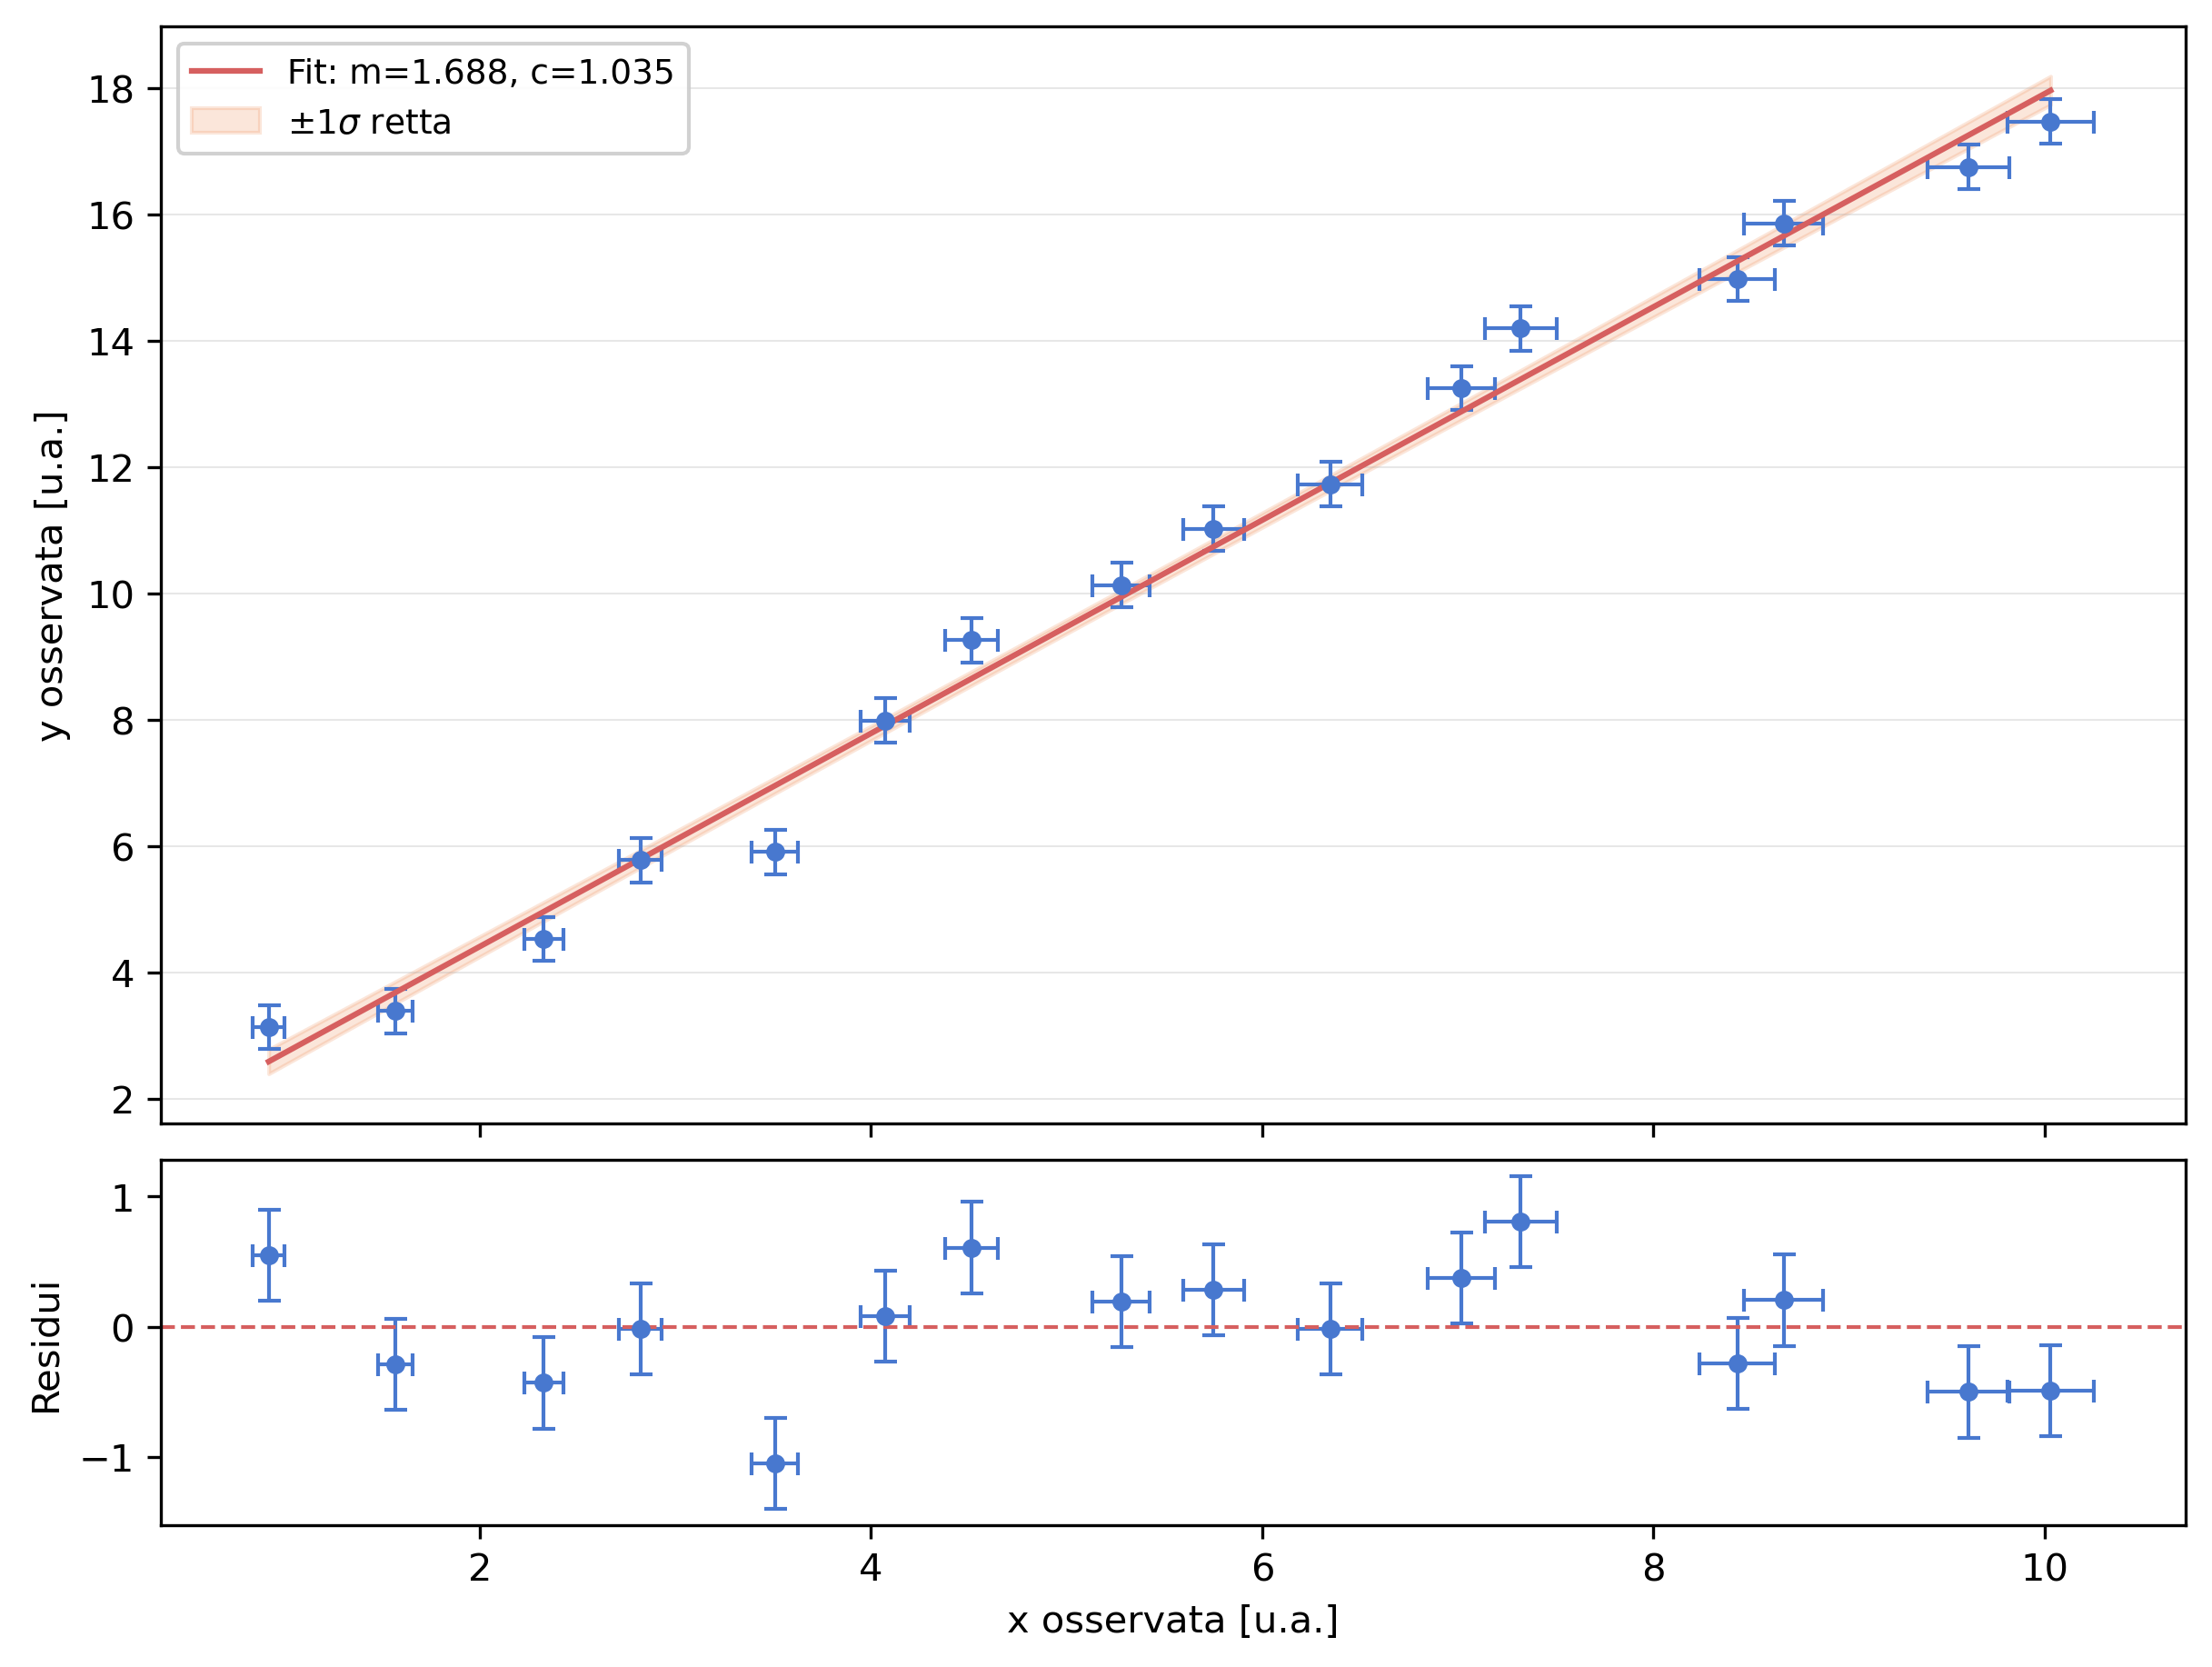

In [6]:
mlt.lin_fit(
    x_obs,
    y_obs,
    sigma_y_sigma_x,
    sigma_x=sigma_x,
    xlabel="x osservata [u.a.]",
    ylabel="y osservata [u.a.]",
    band=True,
    legend_coefficient=True,
)


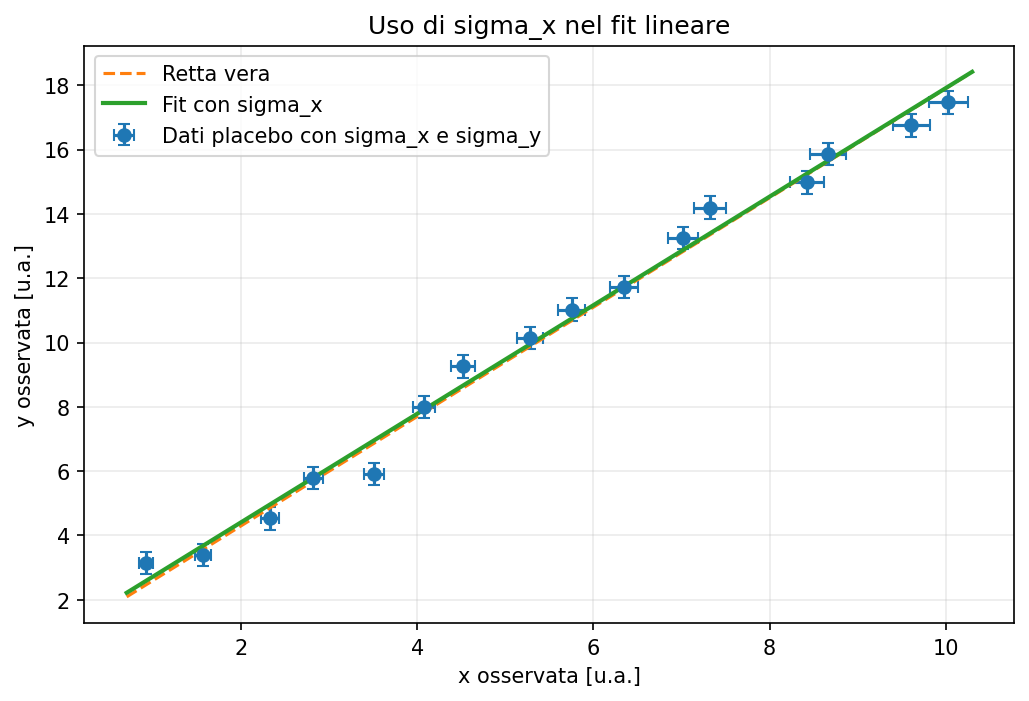

In [7]:
x_grid = np.linspace(x_true_sigma_x.min() - 0.3, x_true_sigma_x.max() + 0.3, 300)

plt.figure(figsize=(8, 5), dpi=150)
plt.errorbar(
    x_obs,
    y_obs,
    xerr=sigma_x,
    yerr=sigma_y_sigma_x,
    fmt="o",
    capsize=3,
    label="Dati placebo con sigma_x e sigma_y",
)
plt.plot(
    x_grid,
    m_true_sigma_x * x_grid + c_true_sigma_x,
    "--",
    linewidth=1.5,
    label="Retta vera",
)
plt.plot(
    x_grid,
    fit_sigma_x["m"] * x_grid + fit_sigma_x["c"],
    linewidth=2,
    label="Fit con sigma_x",
)
plt.xlabel("x osservata [u.a.]")
plt.ylabel("y osservata [u.a.]")
plt.title("Uso di sigma_x nel fit lineare")
plt.grid(alpha=0.25)
plt.legend()
plt.show()
